# Plot Event 74 Hits

This notebook loads the Event 74 hit CSV export, filters the detector rows used in the original script, and renders the hit 3D scatter plot as a notebook figure and PDF file.


## Imports and plotting configuration

The colormap and normalization are kept consistent with the original script so the notebook reproduces the same visual style.


In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

BASE_DIR = Path("../Data")

HIT_CSV_PATH = BASE_DIR / "event74_hits.csv"

HIT_PDF_PATH = BASE_DIR / "event74_py.pdf"

BASE_CMAP = cm.get_cmap("viridis")
BLUE_TO_YELLOW = LinearSegmentedColormap.from_list(
    "viridis_blue_yellow",
    BASE_CMAP(np.linspace(0.25, 1.0, 256)),
)
ADC_NORM = PowerNorm(gamma=2.4, vmin=10, vmax=150, clip=True)


## Helper functions

These cells keep the original script structure but make each step easier to inspect interactively.


In [2]:
def render(
    xs,
    ys,
    zs,
    adcs,
    output_path: Path,
    labels: tuple[str, str, str],
    norm: PowerNorm,
    invert_z: bool = False,
):
    """Render a single 3D scatter plot and save it to PDF.

    Returning the figure and axes lets the notebook display the plot inline
    while still preserving the script behavior of saving a high-resolution
    rasterized PDF copy.
    """
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        xs,
        ys,
        zs,
        c=adcs,
        cmap=BLUE_TO_YELLOW,
        norm=norm,
        s=1.2,
        linewidths=0,
        rasterized=True,
    )

    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])
    ax.set_zlabel(labels[2])
    ax.view_init(elev=24, azim=62)
    if invert_z:
        ax.invert_zaxis()
    ax.grid(False)
    ax.set_facecolor("white")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor((1, 1, 1, 0))

    fig.tight_layout()
    fig.savefig(output_path, dpi=450, bbox_inches="tight")
    return fig, ax


def load_rows(csv_path: Path, coordinates: tuple[str, str, str]) -> tuple[list[float], list[float], list[float], list[float]]:
    """Load the filtered detector rows used in the original plotting script.

    The script keeps only rows with `zelem == 1` and layers in the open
    interval `(7, 55)`. Those cuts are preserved exactly here so the notebook
    reproduces the same event view.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing input CSV: {csv_path}")

    xs = []
    ys = []
    zs = []
    adcs = []

    with csv_path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            zelem = float(row["zelem"])
            if zelem != 1:
                continue

            layer = float(row["layer"])
            if not (7 < layer < 55):
                continue

            xs.append(float(row[coordinates[0]]))
            ys.append(float(row[coordinates[1]]))
            zs.append(float(row[coordinates[2]]))
            adcs.append(float(row["adc"]))

    return xs, ys, zs, adcs


## Load the  data


In [3]:
hit_data = load_rows(HIT_CSV_PATH, ("plot_x", "plot_y", "plot_z"))

print(f"Loaded {len(hit_data[0]):,} hit rows")
print(hit_data)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



## Render the hit plot


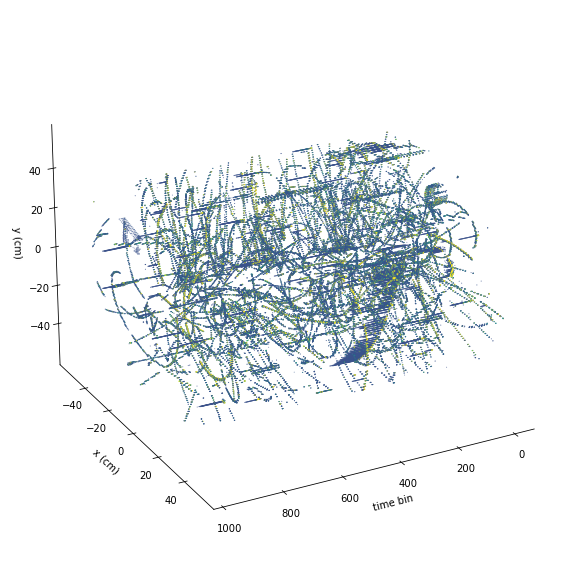

Saved ../Data/event74_py.pdf


In [4]:
fig, ax = render(*hit_data, HIT_PDF_PATH, ("time bin", "x (cm)", "y (cm)"), ADC_NORM)
plt.show()
print(f"Saved {HIT_PDF_PATH}")
